<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Bubble Plots**


Estimated time needed: **30** minutes


In this lab, you will focus on visualizing data.

The dataset will be directly loaded into pandas for analysis and visualization.

You will use various visualization techniques to explore the data and uncover key trends.


## Objectives


In this lab, you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two data features.

-   Visualize composition of data.

-   Visualize comparison of data.


#### Setup: Working with the Database
**Install and import the needed libraries**


In [2]:
!pip install pandas 
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



In [3]:
# Step 1: Download the dataset
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Load the data
df = pd.read_csv("survey-data.csv")

# Display the first few rows of the data to understand its structure
df.head()


--2026-01-12 14:37:37--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  68.0MB/s    in 2.2s    

2026-01-12 14:37:39 (68.0 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]



,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Exploring Data Distributions Using Bubble Plots


#### 1. Bubble Plot for Age vs. Frequency of Participation


- Visualize the relationship between respondents’ age and their participation frequency (`SOPartFreq`) using a bubble plot.

- Use the size of the bubbles to represent their job satisfaction (`JobSat`).


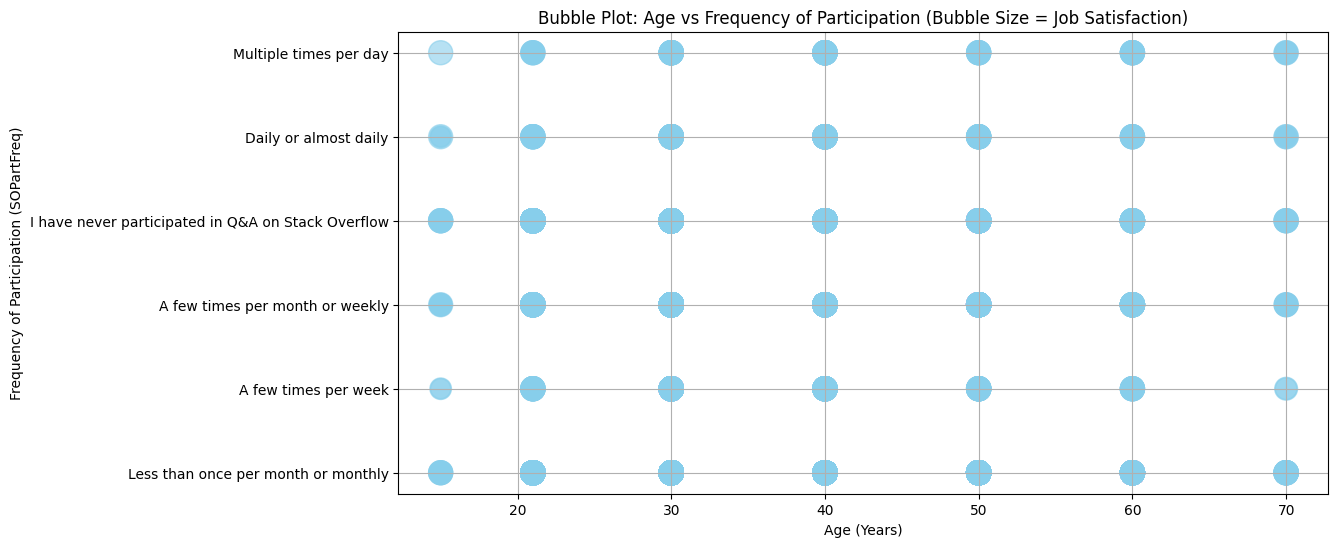

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = df.dropna(subset=['Age', 'SOPartFreq', 'JobSat'])

# -----------------------------
# Step 3: Convert Age to numeric midpoints
# -----------------------------
age_mapping = {
    'Under 18 years old': 15,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70
}
df['Age_numeric'] = df['Age'].map(age_mapping)

# Drop rows with missing Age after mapping
df = df.dropna(subset=['Age_numeric'])

# Ensure JobSat is numeric
df['JobSat'] = pd.to_numeric(df['JobSat'], errors='coerce')
df = df.dropna(subset=['JobSat'])

# -----------------------------
# Step 4: Bubble Plot
# -----------------------------
plt.figure(figsize=(12,6))
plt.scatter(
    x=df['Age_numeric'],
    y=df['SOPartFreq'],
    s=df['JobSat']*30,  # Bubble size scaled by JobSat
    alpha=0.6,
    color='skyblue'
)

plt.title('Bubble Plot: Age vs Frequency of Participation (Bubble Size = Job Satisfaction)')
plt.xlabel('Age (Years)')
plt.ylabel('Frequency of Participation (SOPartFreq)')
plt.grid(True)
plt.show()


#### 2. Bubble Plot for Compensation vs. Job Satisfaction


-Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSat`).

- Use the size of the bubbles to represent respondents’ age.


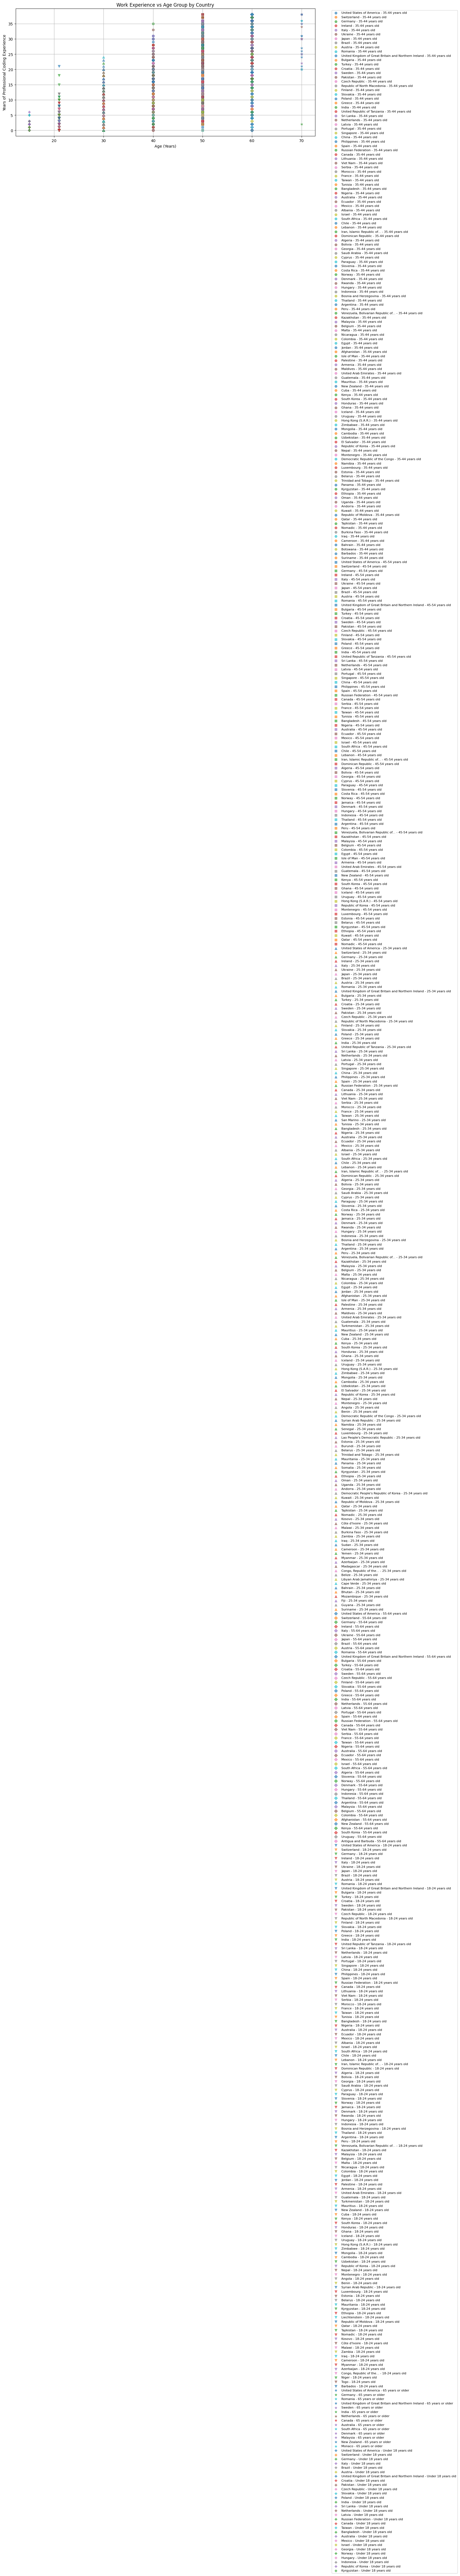

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# -----------------------------
# Step 2: Filter valid data
# -----------------------------
df = df.dropna(subset=['YearsCodePro', 'Age', 'Country'])

# -----------------------------
# Step 3: Convert YearsCodePro to numeric
# -----------------------------
df['YearsCodePro'] = df['YearsCodePro'].replace({
    'Less than 1 year': 0,
    'More than 50 years': 50
})
df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'], errors='coerce')
df = df.dropna(subset=['YearsCodePro'])

# -----------------------------
# Step 4: Optionally filter extreme outliers
# -----------------------------
upper_limit = df['YearsCodePro'].quantile(0.99)
df = df[df['YearsCodePro'] <= upper_limit]

# -----------------------------
# Step 5: Map Age to numeric midpoints for plotting
# -----------------------------
age_mapping = {
    'Under 18 years old': 15,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70
}
df['Age_numeric'] = df['Age'].map(age_mapping)

# -----------------------------
# Step 6: Prepare markers and colors
# -----------------------------
age_groups = df['Age'].unique()
markers = ['o', 's', '^', 'D', 'v', '*', 'P']  # Different markers for age groups
age_marker_map = {age: markers[i % len(markers)] for i, age in enumerate(age_groups)}

countries = df['Country'].unique()
colors = plt.cm.tab10.colors  # Up to 10 colors
country_color_map = {country: colors[i % len(colors)] for i, country in enumerate(countries)}

# -----------------------------
# Step 7: Scatter Plot
# -----------------------------
plt.figure(figsize=(14,6))

for age in age_groups:
    for country in countries:
        subset = df[(df['Age'] == age) & (df['Country'] == country)]
        if not subset.empty:
            plt.scatter(
                subset['Age_numeric'],
                subset['YearsCodePro'],
                alpha=0.6,
                marker=age_marker_map[age],
                color=country_color_map[country],
                label=f"{country} - {age}"
            )

plt.xlabel('Age (Years)')
plt.ylabel('Years of Professional Coding Experience')
plt.title('Work Experience vs Age Group by Country')
plt.grid(True)

# -----------------------------
# Step 8: Handle legend (remove duplicates)
# -----------------------------
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.show()


### Task 2: Analyzing Relationships Using Bubble Plots


#### 1. Bubble Plot of Technology Preferences by Age

- Visualize the popularity of programming languages respondents have worked with (`LanguageHaveWorkedWith`) across age groups.

- Use bubble size to represent the frequency of each language.



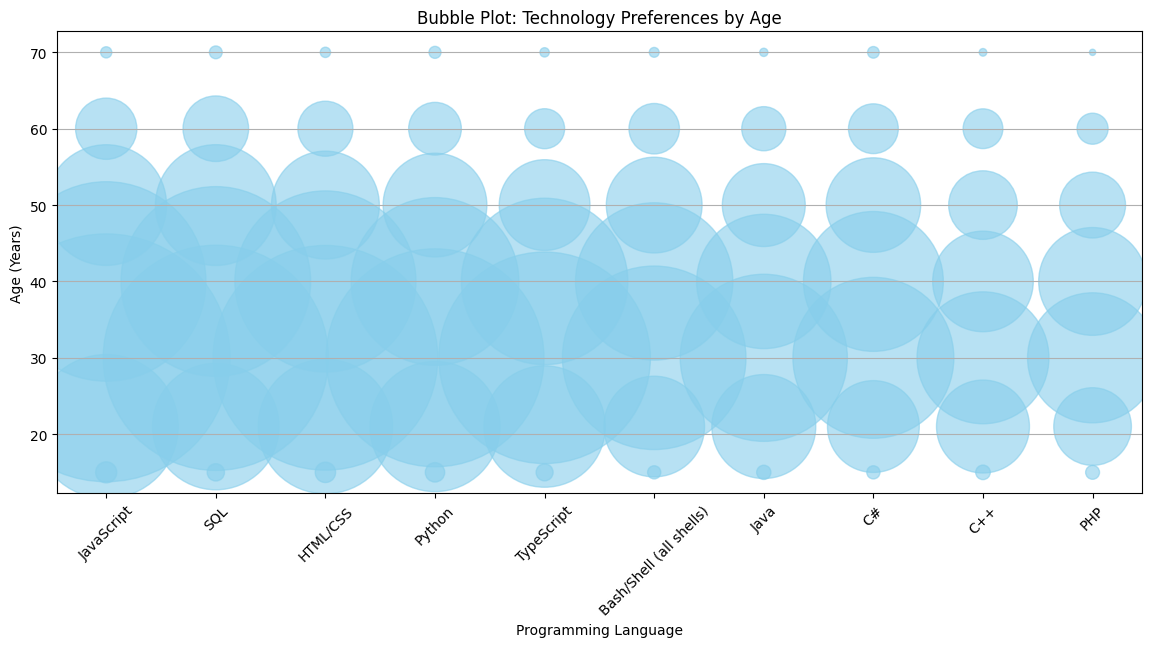

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# -----------------------------
# Step 2: Filter valid data
# -----------------------------
df = df.dropna(subset=['Age', 'LanguageHaveWorkedWith'])

# -----------------------------
# Step 3: Explode languages into separate rows
# -----------------------------
rows = []
for _, row in df.iterrows():
    languages = row['LanguageHaveWorkedWith'].split(';')
    for lang in languages:
        rows.append({'Age': row['Age'], 'Language': lang.strip()})

df_lang = pd.DataFrame(rows)

# -----------------------------
# Step 4: Aggregate frequency by Age and Language
# -----------------------------
freq_table = df_lang.groupby(['Age', 'Language']).size().reset_index(name='Frequency')

# -----------------------------
# Step 5: Filter Top 10 Languages for readability
# -----------------------------
top_languages = df_lang['Language'].value_counts().head(10).index.tolist()
freq_table = freq_table[freq_table['Language'].isin(top_languages)]

# -----------------------------
# Step 6: Map Age to numeric midpoints for plotting
# -----------------------------
age_mapping = {
    'Under 18 years old': 15,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70
}
freq_table['Age_numeric'] = freq_table['Age'].map(age_mapping)

# -----------------------------
# Step 7: Bubble Plot
# -----------------------------
plt.figure(figsize=(14,6))

# Map languages to x-axis positions
language_order = top_languages
x = [language_order.index(lang) for lang in freq_table['Language']]
y = freq_table['Age_numeric']
sizes = freq_table['Frequency'] * 5  # Bubble size scaled by frequency

plt.scatter(x, y, s=sizes, alpha=0.6, color='skyblue')

plt.xticks(range(len(language_order)), language_order, rotation=45)
plt.xlabel('Programming Language')
plt.ylabel('Age (Years)')
plt.title('Bubble Plot: Technology Preferences by Age')
plt.grid(True, axis='y')
plt.show()


#### 2. Bubble Plot for Preferred Databases vs. Job Satisfaction

- Explore the relationship between preferred databases (`DatabaseWantToWorkWith`) and job satisfaction.

- Use bubble size to indicate the number of respondents for each database.


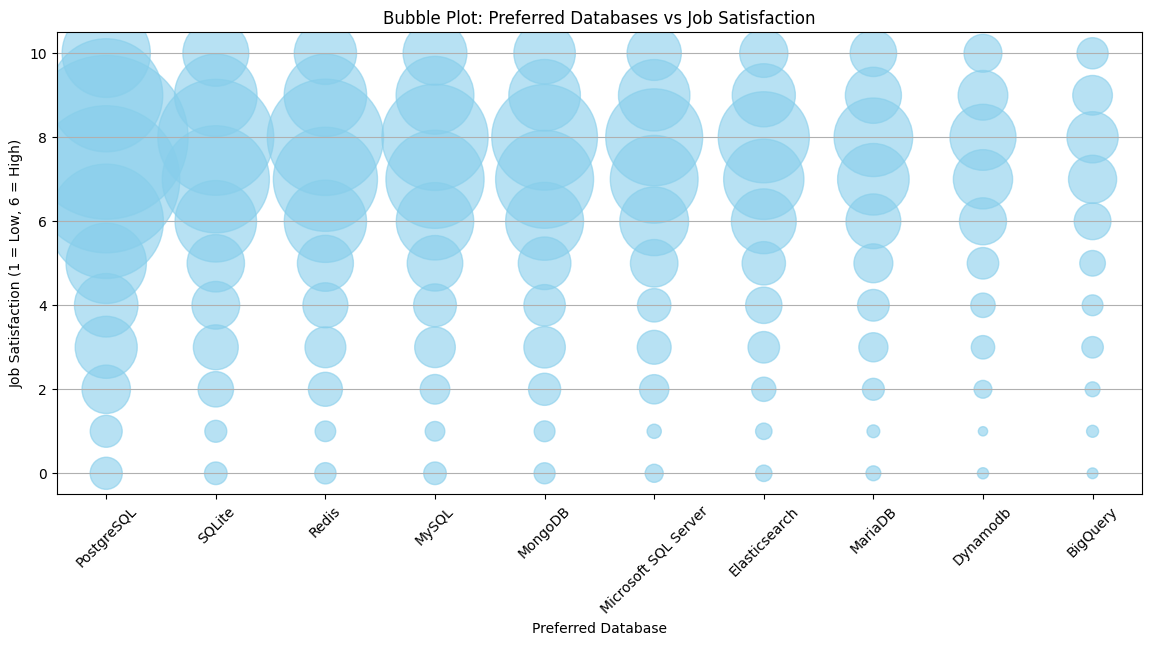

In [7]:

# -----------------------------
# Step 2: Filter valid data
# -----------------------------
df = df.dropna(subset=['DatabaseWantToWorkWith', 'JobSat'])
df['JobSat'] = pd.to_numeric(df['JobSat'], errors='coerce')
df = df.dropna(subset=['JobSat'])

# -----------------------------
# Step 3: Explode multiple databases into separate rows
# -----------------------------
rows = []
for _, row in df.iterrows():
    databases = row['DatabaseWantToWorkWith'].split(';')
    for db in databases:
        rows.append({'Database': db.strip(), 'JobSat': row['JobSat']})

df_db = pd.DataFrame(rows)

# -----------------------------
# Step 4: Aggregate frequency by Database and JobSat
# -----------------------------
freq_table = df_db.groupby(['Database', 'JobSat']).size().reset_index(name='Frequency')

# -----------------------------
# Step 5: Filter top 10 databases for readability
# -----------------------------
top_dbs = df_db['Database'].value_counts().head(10).index.tolist()
freq_table = freq_table[freq_table['Database'].isin(top_dbs)]

# -----------------------------
# Step 6: Map databases to x-axis positions
# -----------------------------
database_order = top_dbs
x = [database_order.index(db) for db in freq_table['Database']]
y = freq_table['JobSat']
sizes = freq_table['Frequency'] * 5  # Bubble size scaled by number of respondents

# -----------------------------
# Step 7: Bubble Plot
# -----------------------------
plt.figure(figsize=(14,6))
plt.scatter(x, y, s=sizes, alpha=0.6, color='skyblue')

plt.xticks(range(len(database_order)), database_order, rotation=45)
plt.xlabel('Preferred Database')
plt.ylabel('Job Satisfaction (1 = Low, 6 = High)')
plt.title('Bubble Plot: Preferred Databases vs Job Satisfaction')
plt.grid(True, axis='y')
plt.show()

### Task 3: Comparing Data Using Bubble Plots


#### 1. Bubble Plot for Compensation Across Developer Roles

- Visualize compensation (`ConvertedCompYearly`) across different developer roles (`DevType`).

- Use bubble size to represent job satisfaction.


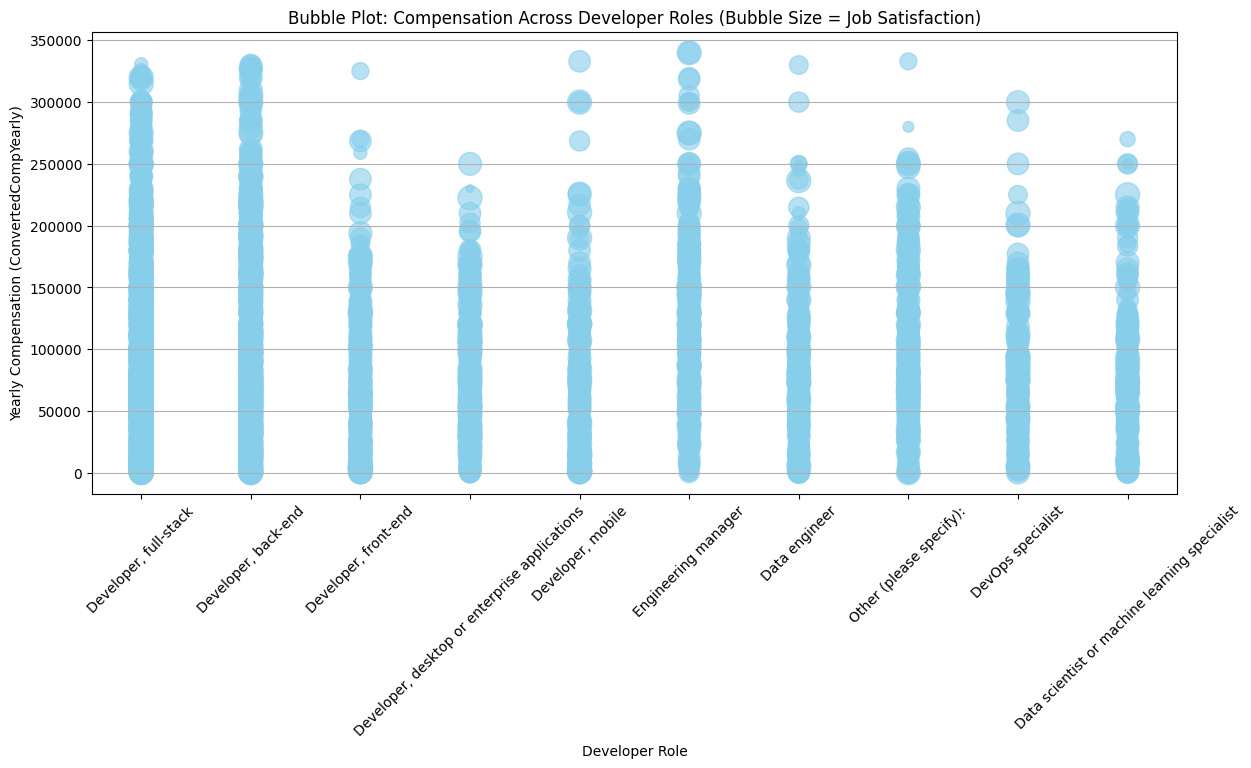

In [8]:
df = df.dropna(subset=['DevType', 'ConvertedCompYearly', 'JobSat'])
df['JobSat'] = pd.to_numeric(df['JobSat'], errors='coerce')
df = df.dropna(subset=['JobSat'])

# -----------------------------
# Step 3: Explode multiple DevTypes into separate rows
# -----------------------------
rows = []
for _, row in df.iterrows():
    roles = row['DevType'].split(';')
    for role in roles:
        rows.append({
            'DevType': role.strip(),
            'ConvertedCompYearly': row['ConvertedCompYearly'],
            'JobSat': row['JobSat']
        })

df_roles = pd.DataFrame(rows)

# -----------------------------
# Step 4: Filter top 10 developer roles for readability
# -----------------------------
top_roles = df_roles['DevType'].value_counts().head(10).index.tolist()
df_top_roles = df_roles[df_roles['DevType'].isin(top_roles)]

# -----------------------------
# Step 5: Remove extreme compensation outliers (optional)
# -----------------------------
upper_limit = df_top_roles['ConvertedCompYearly'].quantile(0.99)
df_top_roles = df_top_roles[df_top_roles['ConvertedCompYearly'] <= upper_limit]

# -----------------------------
# Step 6: Map DevType to x-axis positions
# -----------------------------
role_order = top_roles
x = [role_order.index(role) for role in df_top_roles['DevType']]
y = df_top_roles['ConvertedCompYearly']
sizes = df_top_roles['JobSat'] * 30  # Bubble size scaled by JobSat

# -----------------------------
# Step 7: Bubble Plot
# -----------------------------
plt.figure(figsize=(14,6))
plt.scatter(x, y, s=sizes, alpha=0.6, color='skyblue')

plt.xticks(range(len(role_order)), role_order, rotation=45)
plt.xlabel('Developer Role')
plt.ylabel('Yearly Compensation (ConvertedCompYearly)')
plt.title('Bubble Plot: Compensation Across Developer Roles (Bubble Size = Job Satisfaction)')
plt.grid(True, axis='y')
plt.show()

#### 2. Bubble Plot for Collaboration Tools by Age

- Visualize the relationship between the collaboration tools used (`NEWCollabToolsHaveWorkedWith`) and age groups.

- Use bubble size to represent the frequency of tool usage.


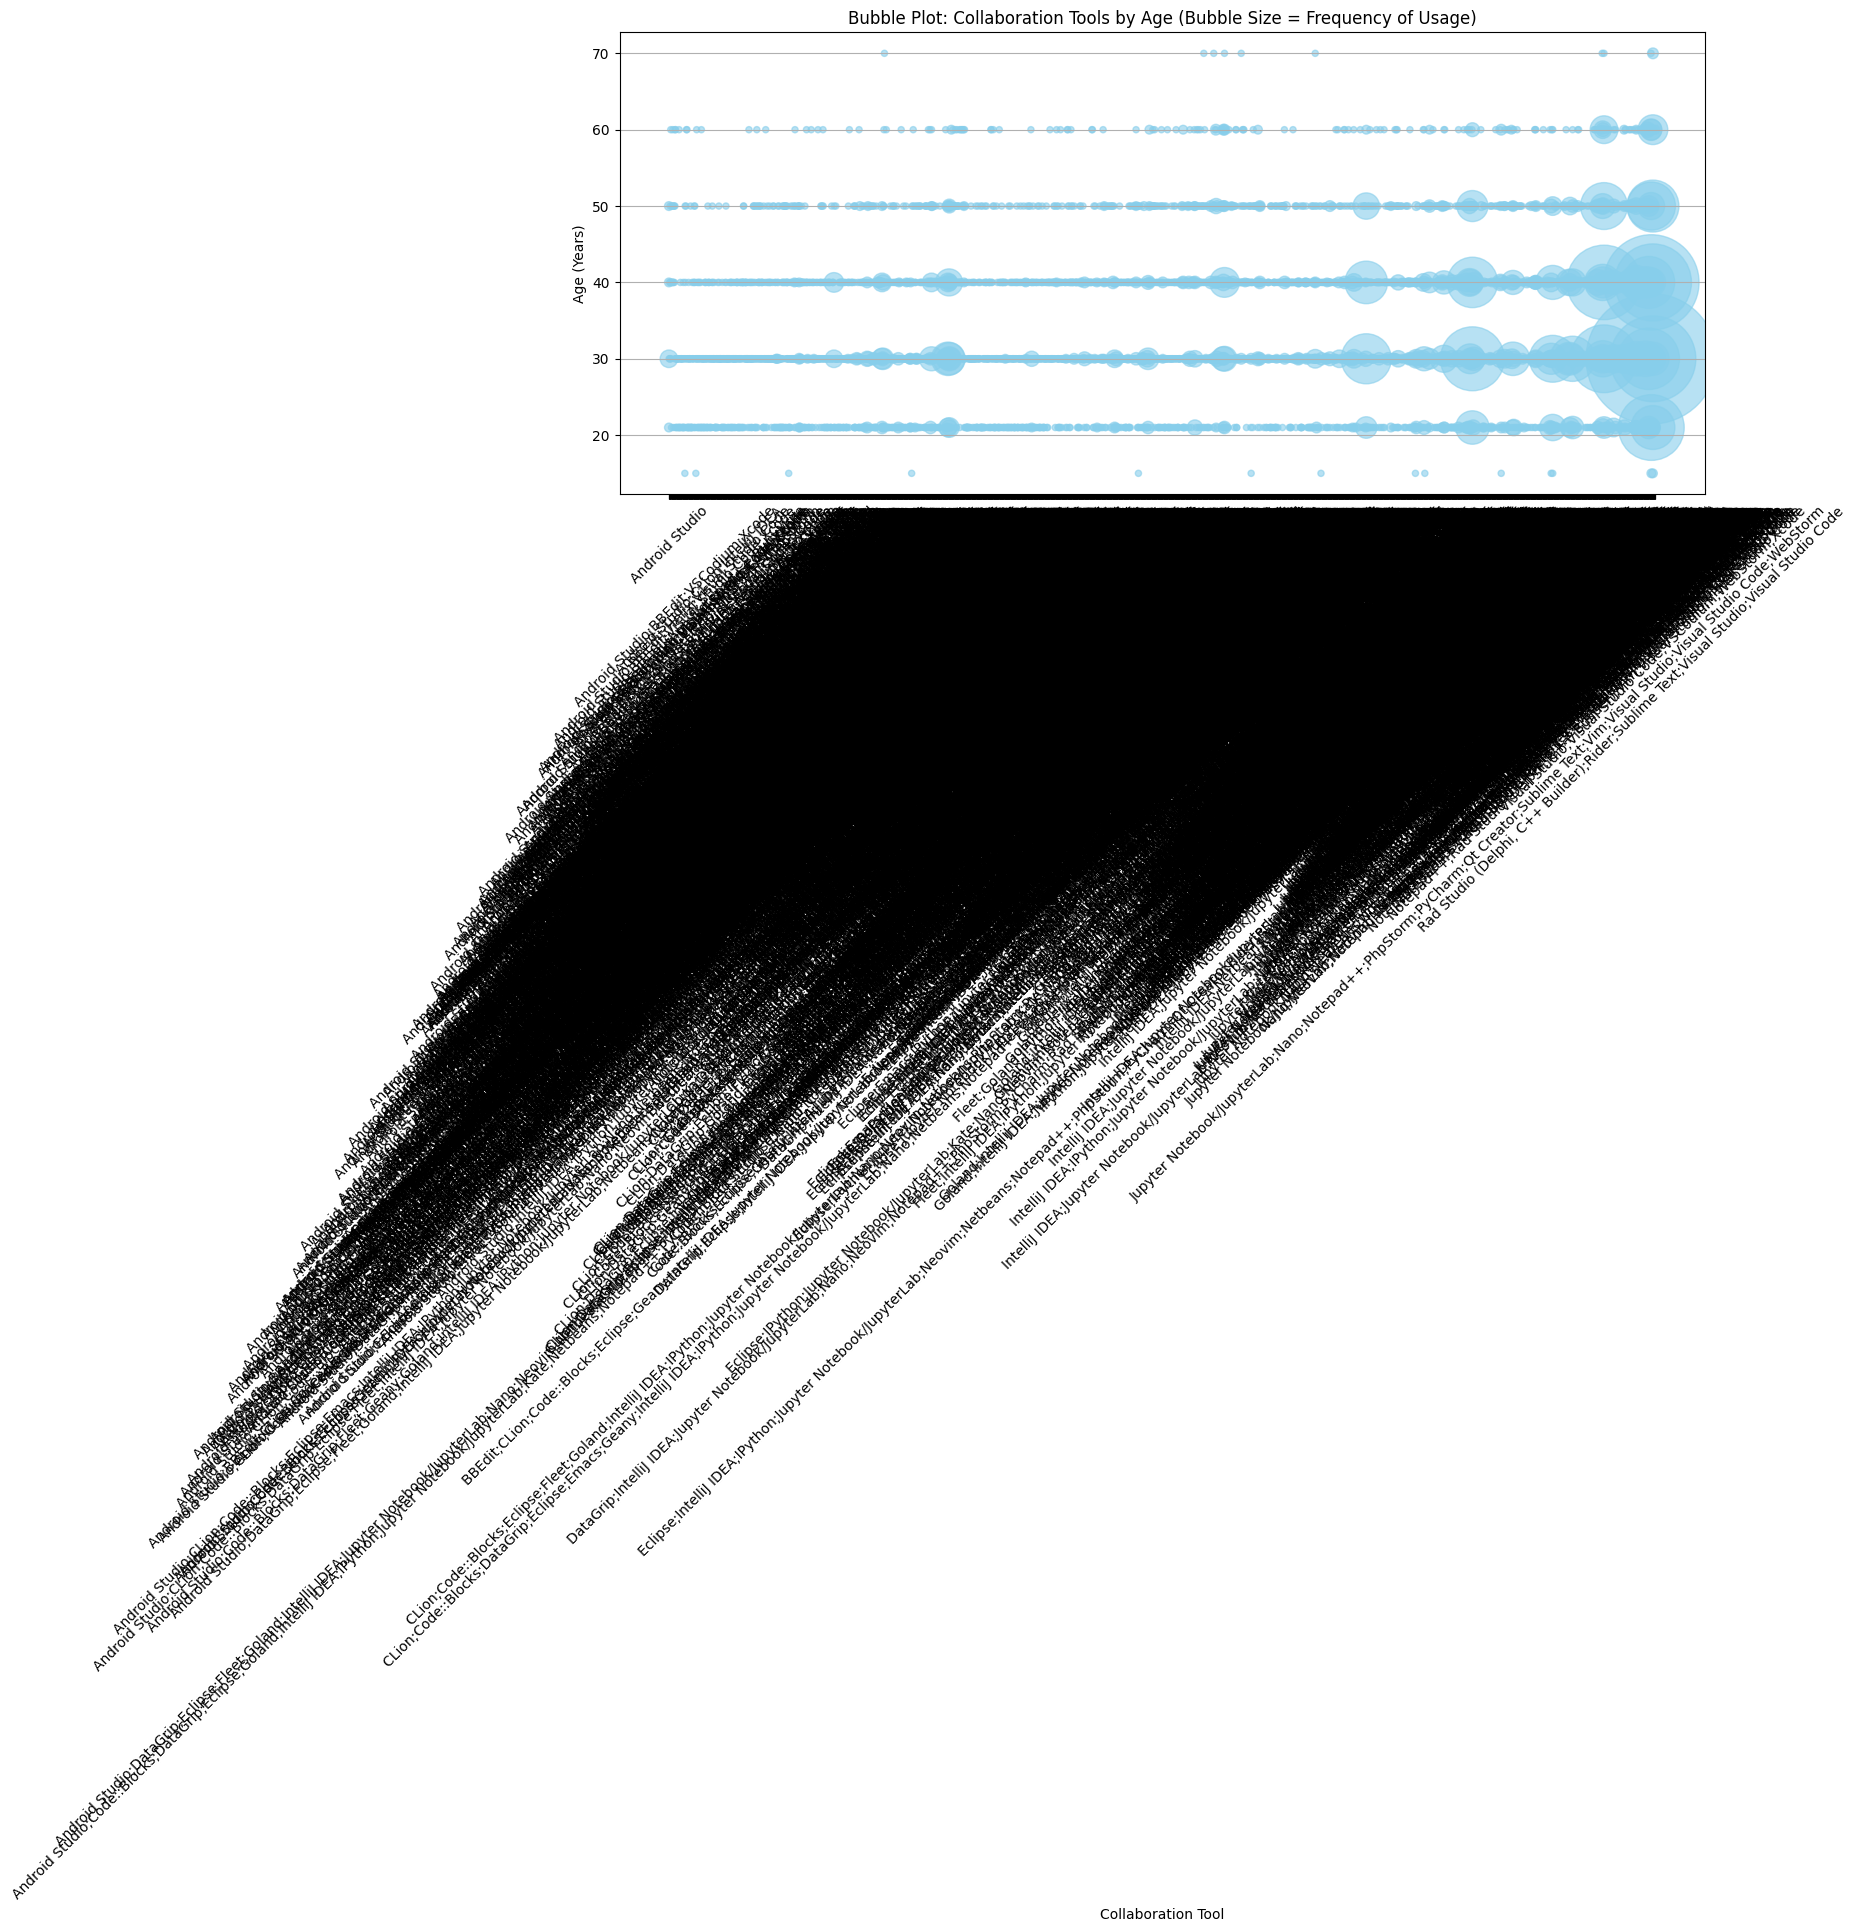

In [9]:
import pandas as pd
import matplotlib.pyplot as plt



# -----------------------------
# Step 1: Map Age groups to numeric midpoints
# -----------------------------
age_mapping = {
    'Under 18 years old': 15,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70
}

if 'Age' not in df.columns:
    raise KeyError("Column 'Age' not found in survey_data!")

df['Age_numeric'] = df['Age'].map(age_mapping)

# -----------------------------
# Step 2: Use the correct column for collaboration tools
# -----------------------------
tool_column = 'NEWCollabToolsHaveWorkedWith'
if tool_column not in df.columns:
    raise KeyError(f"Column '{tool_column}' not found in survey_data! Check spelling/case.")

# -----------------------------
# Step 3: Aggregate frequency of tool usage by age group
# -----------------------------
freq_agg = df.groupby([tool_column, 'Age_numeric']).size().reset_index(name='Frequency')

# -----------------------------
# Step 4: Create Bubble Plot
# -----------------------------
plt.figure(figsize=(14,6))

# Order tools for x-axis
tool_order = freq_agg[tool_column].unique().tolist()

# Map tools to x-axis positions
x = [tool_order.index(tool) for tool in freq_agg[tool_column]]
y = freq_agg['Age_numeric']
sizes = freq_agg['Frequency'] * 20  # Adjust scaling factor

plt.scatter(x, y, s=sizes, alpha=0.6, color='skyblue')

plt.xticks(range(len(tool_order)), tool_order, rotation=45)
plt.xlabel('Collaboration Tool')
plt.ylabel('Age (Years)')
plt.title('Bubble Plot: Collaboration Tools by Age (Bubble Size = Frequency of Usage)')
plt.grid(True, axis='y')
plt.show()


### Task 4: Visualizing Technology Trends Using Bubble Plots


#### 1. Bubble Plot for Preferred Web Frameworks vs. Job Satisfaction

- Explore the relationship between preferred web frameworks (`WebframeWantToWorkWith`) and job satisfaction.

- Use bubble size to represent the number of respondents.



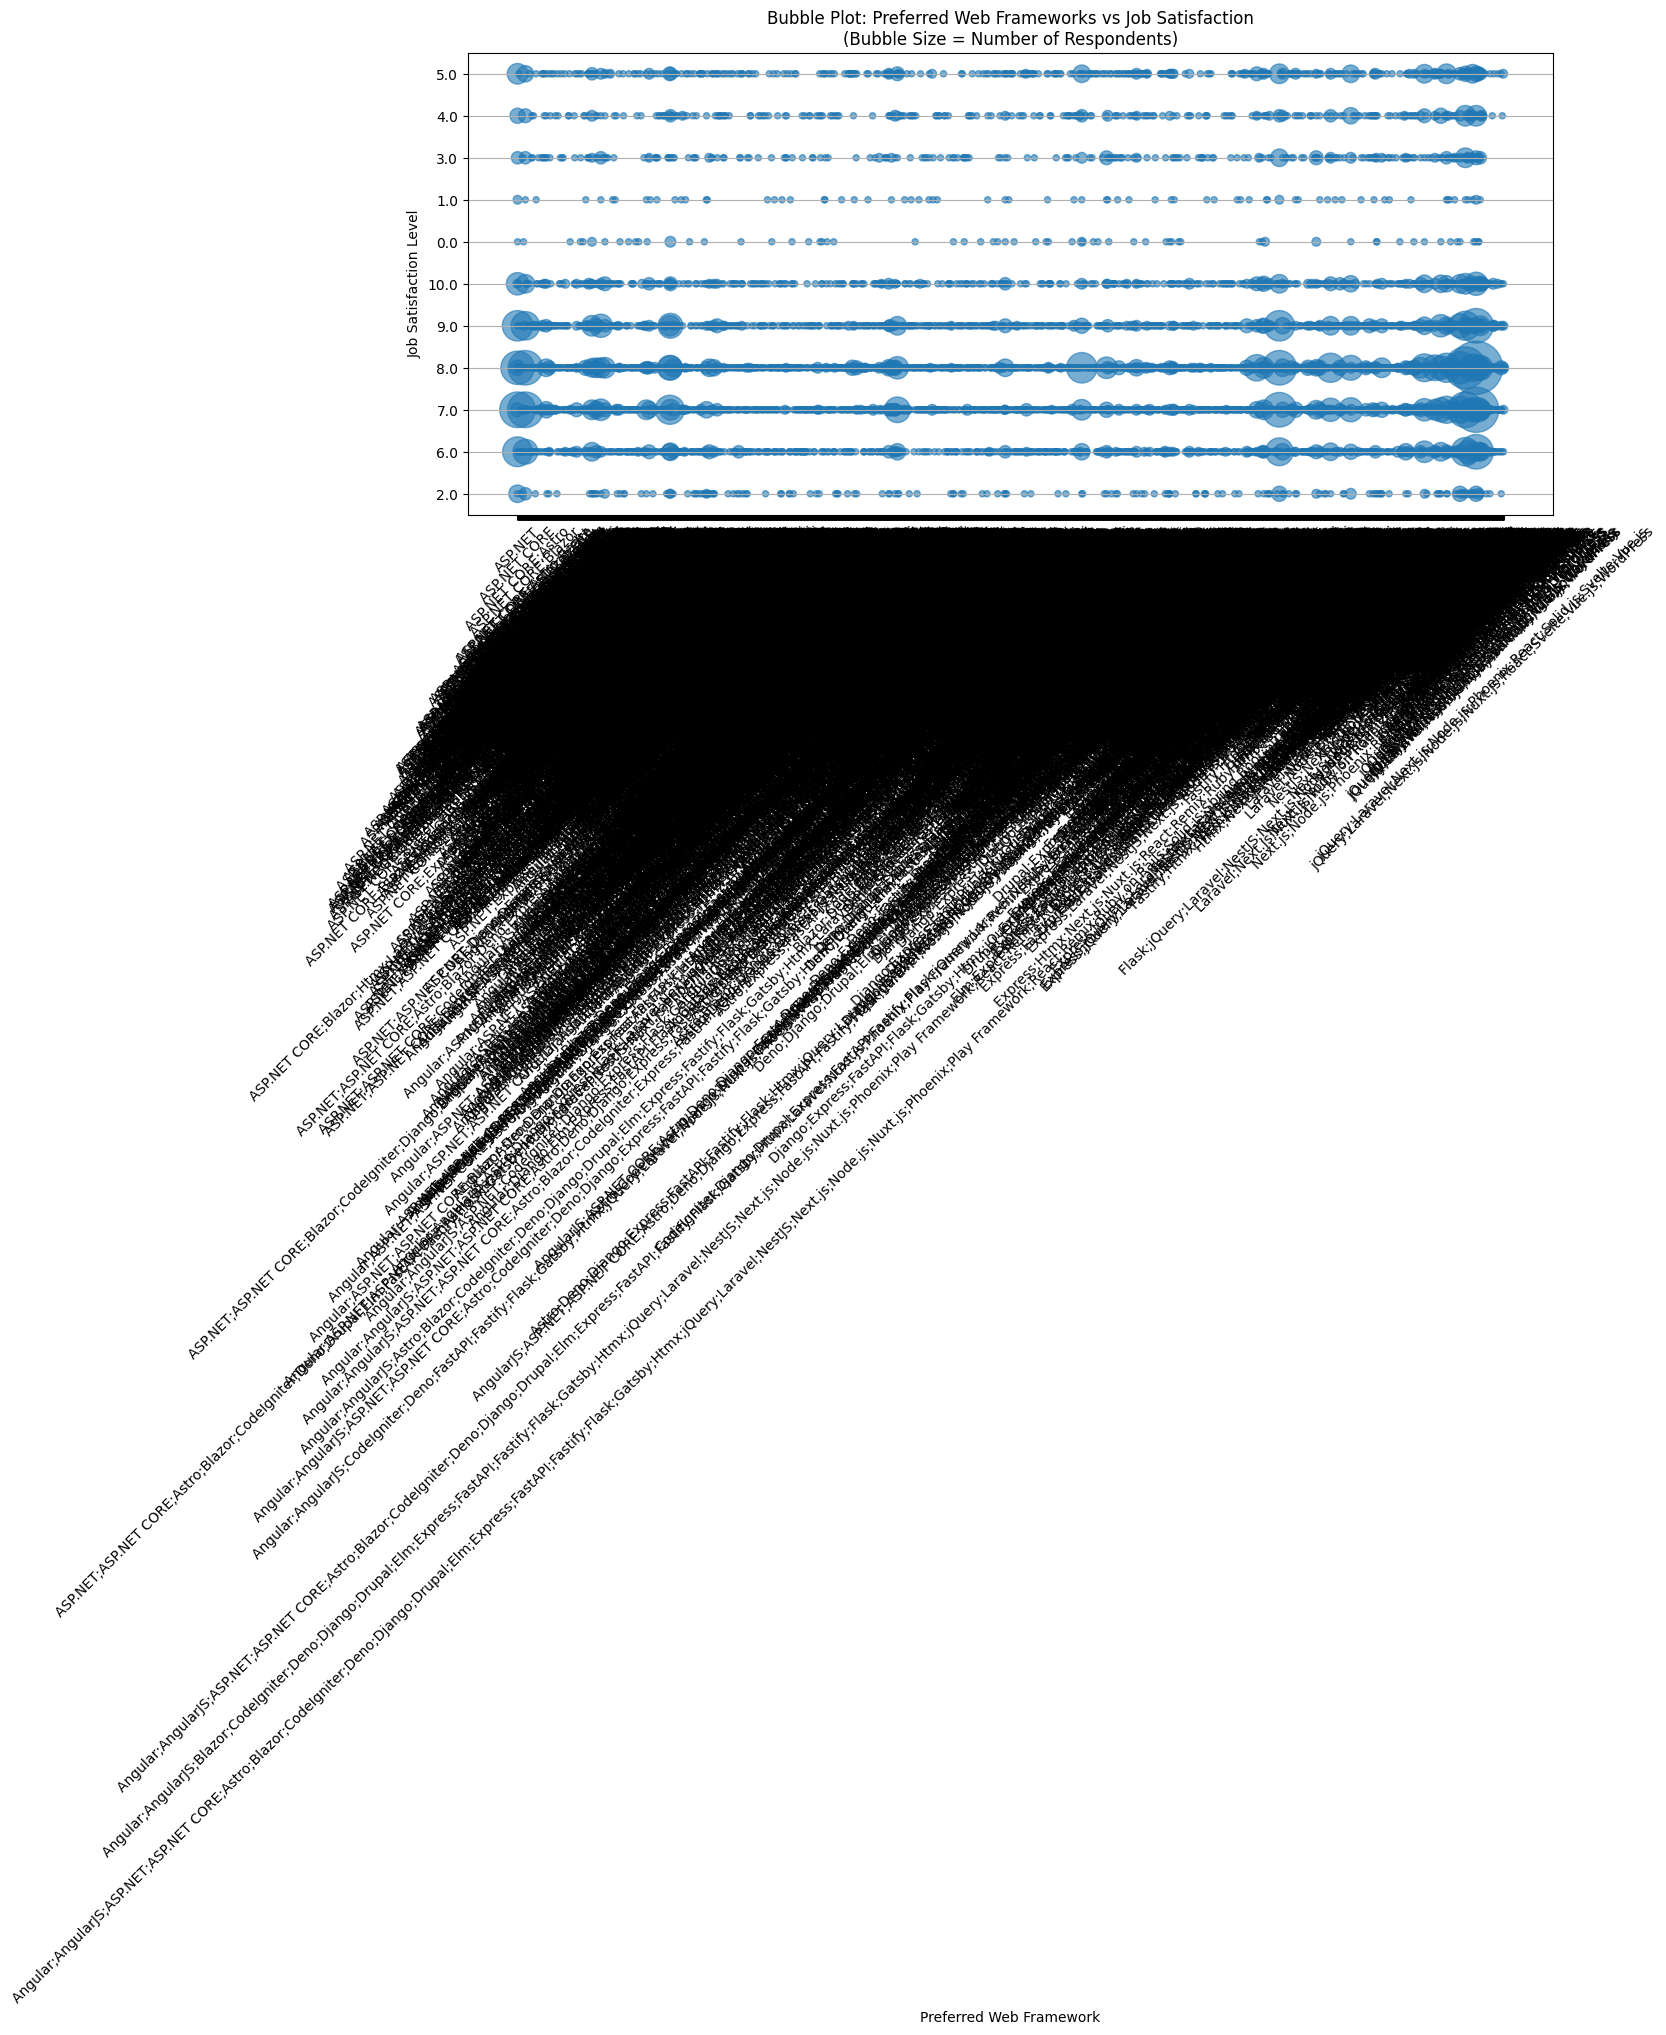

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Step 1: Check required columns
# -----------------------------
required_cols = ['WebframeWantToWorkWith', 'JobSat']
for col in required_cols:
    if col not in df.columns:
        raise KeyError(f"Column '{col}' not found in dataset!")

# -----------------------------
# Step 2: Drop missing values
# -----------------------------
df_web = df[required_cols].dropna()

# -----------------------------
# Step 3: Aggregate frequency
# -----------------------------
freq_agg = (
    df_web
    .groupby(['WebframeWantToWorkWith', 'JobSat'])
    .size()
    .reset_index(name='Frequency')
)

# -----------------------------
# Step 4: Prepare axes
# -----------------------------
# Order frameworks on x-axis
framework_order = freq_agg['WebframeWantToWorkWith'].unique().tolist()

# Order JobSat levels on y-axis
jobsat_order = freq_agg['JobSat'].unique().tolist()

x = [framework_order.index(fw) for fw in freq_agg['WebframeWantToWorkWith']]
y = [jobsat_order.index(js) for js in freq_agg['JobSat']]
sizes = freq_agg['Frequency'] * 20  # Bubble size scaling

# -----------------------------
# Step 5: Create Bubble Plot
# -----------------------------
plt.figure(figsize=(14, 6))
plt.scatter(x, y, s=sizes, alpha=0.6)

plt.xticks(range(len(framework_order)), framework_order, rotation=45)
plt.yticks(range(len(jobsat_order)), jobsat_order)

plt.xlabel("Preferred Web Framework")
plt.ylabel("Job Satisfaction Level")
plt.title("Bubble Plot: Preferred Web Frameworks vs Job Satisfaction\n(Bubble Size = Number of Respondents)")

plt.grid(True, axis='y')
plt.show()


#### 2. Bubble Plot for Admired Technologies Across Countries

- Visualize the distribution of admired technologies (`LanguageAdmired`) across different countries (`Country`).

- Use bubble size to represent the frequency of admiration.



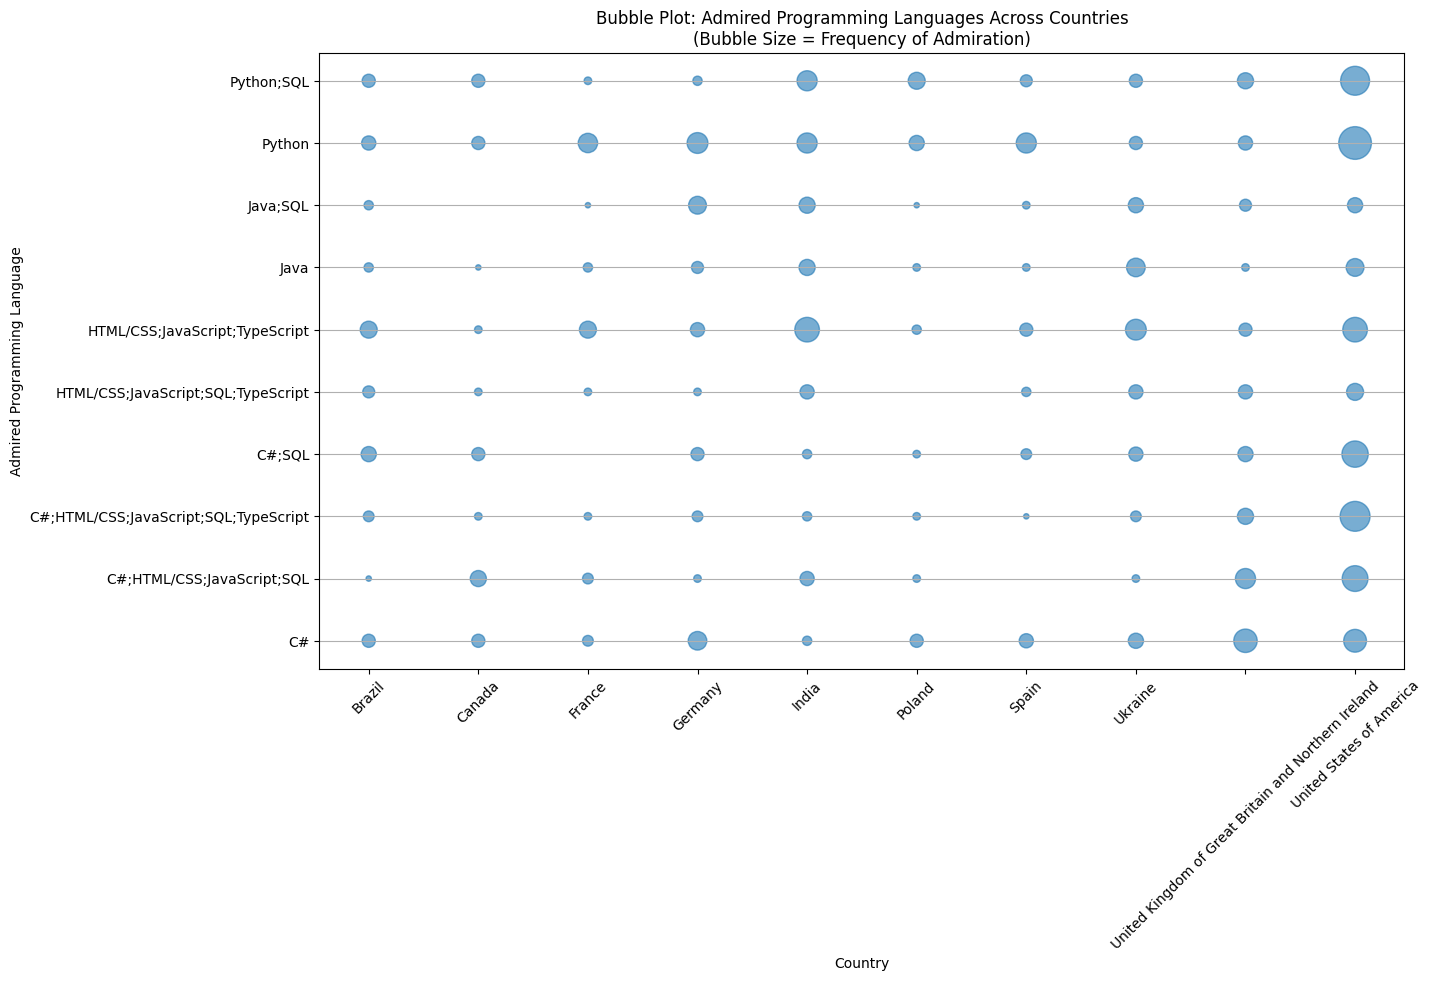

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Step 1: Check required columns
# -----------------------------
required_cols = ['LanguageAdmired', 'Country']
for col in required_cols:
    if col not in df.columns:
        raise KeyError(f"Column '{col}' not found in dataset!")

# -----------------------------
# Step 2: Drop missing values
# -----------------------------
df_lang = df[required_cols].dropna()

# -----------------------------
# Step 3: (Optional) Keep top countries & languages to reduce clutter
# -----------------------------
top_countries = df_lang['Country'].value_counts().nlargest(10).index
top_languages = df_lang['LanguageAdmired'].value_counts().nlargest(10).index

df_lang = df_lang[
    df_lang['Country'].isin(top_countries) &
    df_lang['LanguageAdmired'].isin(top_languages)
]

# -----------------------------
# Step 4: Aggregate frequency
# -----------------------------
freq_agg = (
    df_lang
    .groupby(['Country', 'LanguageAdmired'])
    .size()
    .reset_index(name='Frequency')
)

# -----------------------------
# Step 5: Prepare axes
# -----------------------------
country_order = freq_agg['Country'].unique().tolist()
language_order = freq_agg['LanguageAdmired'].unique().tolist()

x = [country_order.index(c) for c in freq_agg['Country']]
y = [language_order.index(l) for l in freq_agg['LanguageAdmired']]
sizes = freq_agg['Frequency'] * 15  # Bubble size scaling

# -----------------------------
# Step 6: Create Bubble Plot
# -----------------------------
plt.figure(figsize=(14, 8))
plt.scatter(x, y, s=sizes, alpha=0.6)

plt.xticks(range(len(country_order)), country_order, rotation=45)
plt.yticks(range(len(language_order)), language_order)

plt.xlabel("Country")
plt.ylabel("Admired Programming Language")
plt.title(
    "Bubble Plot: Admired Programming Languages Across Countries\n"
    "(Bubble Size = Frequency of Admiration)"
)

plt.grid(True, axis='y')
plt.show()


## Final Step: Review


After completing the lab, you will have extensively used bubble plots to gain insights into developer community preferences, demographics, compensation trends, and job satisfaction.


## Summary


After completing this lab, you will be able to:

- Create and interpret bubble plots to analyze relationships and compositions within datasets.

- Use bubble plots to explore developer preferences, compensation trends, and satisfaction levels.

- Apply bubble plots to visualize complex relationships involving multiple dimensions effectively.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-10-29|1.2|Madhusudhan Moole|Updated lab|
|2024-10-16|1.1|Madhusudhan Moole|Updated lab|
|2024-10-15|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
